In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import pearsonr

In [32]:
df = pd.read_csv('data/metric_means.csv', index_col=0)
df = df.drop(columns=['crosswind_speed'])
df = df.dropna()

In [33]:
def show_correlation(df: pd.DataFrame, target_feature: str, feature: str, no_std=False):
    
    fig, ax = plt.subplots(figsize=(7, 6))
    # Draw error bars (Matplotlib)
    if no_std == False:
        plt.errorbar(
            df[target_feature],
            df[feature],
            yerr=df[feature + '_std_dev'],
            fmt='o',
            markerfacecolor='steelblue',
            markeredgecolor='black',
            ecolor=(0.5, 0.5, 0.5, 0.3),
            elinewidth=1,
            alpha=0.8,
            capsize=3,
            label='Mean ± SD'
            )

        # draw points and regression plot
        sns.regplot(
            data=df,
            x=target_feature,
            y=feature,
            ax=ax,
            scatter_kws={"alpha": 0.8, 'color': 'steelblue', 'edgecolor': 'black'},
            line_kws={"color": "red", 'alpha': 0.8},
            )

    else:
        # draw points and regression plot
        sns.regplot(
            data=df,
            x=target_feature,
            y=feature,
            ax=ax,
            scatter_kws={"alpha": 0.8, 'color': 'steelblue', 'edgecolor': 'black', 'zorder': 3},
            line_kws={"color": "red", 'alpha': 0.8},
            )



    # Compute correlation
    r, p = pearsonr(df[target_feature], df[feature])
    r, p = np.round((r, p), 3)

    ax.set_title(f"r={r}, p={p}")
    ax.grid(color="lightgrey")

    ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
    ax.tick_params(length=0)

    plt.tight_layout()
    plt.show()


In [34]:
def show_correlations(df: pd.DataFrame, target_feature: str, features: list):
    """
    Show regression plots and correlation coefficients between one chosen feature
    and all other numeric features in the dataframe.
    """
    # Select numeric columns only
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remove the target feature itself
    n_features = len(features)
    if n_features == 0:
        print("No other numeric columns to correlate with.")
        return

    # --- Determine subplot grid size dynamically ---
    n_cols = n_features
    n_rows = 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
    axes = axes.flatten()  # flatten for easy iteration

    # --- Loop through all features and plot ---
    for i, feature in enumerate(features):
        ax = axes[i]

        if feature != 'n_frames' and feature != 'n_geese' and 'std_dev' not in feature:
            # Draw error bars (Matplotlib)
            ax.errorbar(
                df[target_feature],
                df[feature],
                yerr=df[feature + '_std_dev'],
                fmt='o',
                markerfacecolor='steelblue',
                markeredgecolor='black',
                ecolor=(0.5, 0.5, 0.5, 0.3),
                elinewidth=1,
                alpha=0.8,
                capsize=3,
                label='Mean ± SD'
                )

        # draw points and regression plot
        sns.regplot(
            data=df,
            x=target_feature,
            y=feature,
            ax=ax,
            scatter_kws={"alpha": 0.8, 'color': 'steelblue', 'edgecolor': 'black', 'zorder': 3},
            line_kws={"color": "red", 'alpha': 0.8},
        )

        # Compute correlation
        r, p = pearsonr(df[target_feature], df[feature])
        r, p = np.round((r, p), 3)

        ax.set_title(f"{feature} vs {target_feature}\n(r={r}, p={p})")
        ax.grid(color="lightgrey")

        ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
        ax.tick_params(length=0)

    # Hide empty subplots if any
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [35]:
features = [
    'n_frames',
    "normalized_velocity_alignment",
    "velocity_deviation",
    "sidewise_acceleration_deviation",
    "longitudinal_acceleration_deviation",
    "first_pca_component",
    "second_pca_component",
    "first_pca_component_velocity_alignment",
    "second_pca_component_velocity_alignment",
    "first_pca_component_horizontal_axis_alignment",
    "first_pca_component_z_axis_alignment",
    "second_pca_component_horizontal_axis_alignment",
    "second_pca_component_z_axis_alignment",
]

In [36]:
print(f'Dropping {len(df[df['n_frames'] <= 180])} data_points out of {len(df)}')
df = df[df['n_frames'] > 180]

Dropping 4 data_points out of 164


In [37]:
print(f'Dropping {len(df[df['first_pca_component'] >= 4])} data_points out of {len(df)}')
df = df[df['first_pca_component'] < 4]
df.describe()

Dropping 9 data_points out of 160


,n_geese,n_frames,normalized_velocity_alignment,normalized_velocity_alignment_std_dev,velocity_deviation,velocity_deviation_std_dev,sidewise_acceleration_deviation,sidewise_acceleration_deviation_std_dev,longitudinal_acceleration_deviation,longitudinal_acceleration_deviation_std_dev,...,second_pca_component_velocity_alignment,second_pca_component_velocity_alignment_std_dev,first_pca_component_horizontal_axis_alignment,first_pca_component_horizontal_axis_alignment_std_dev,first_pca_component_z_axis_alignment,first_pca_component_z_axis_alignment_std_dev,second_pca_component_horizontal_axis_alignment,second_pca_component_horizontal_axis_alignment_std_dev,second_pca_component_z_axis_alignment,second_pca_component_z_axis_alignment_std_dev
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,...,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,23.556291,520.145695,0.998171,0.001100,0.867471,0.250134,1.494284,0.404776,0.322157,0.140603,...,0.544837,0.272716,0.694954,0.223715,0.371194,0.212307,0.421593,0.247500,0.512808,0.269740
std,15.573326,130.007712,0.001814,0.001109,0.427797,0.166047,0.579065,0.349792,0.146234,0.123547,...,0.124143,0.046902,0.150242,0.086221,0.144569,0.068652,0.123774,0.057563,0.118126,0.044800
min,2.000000,235.000000,0.989044,0.000026,0.152738,0.034203,0.259887,0.089202,0.064296,0.019732,...,0.252590,0.088928,0.227773,0.012275,0.076822,0.052251,0.093773,0.062234,0.153635,0.114335
25%,11.500000,436.000000,0.997412,0.000264,0.458727,0.131814,0.984410,0.227569,0.212203,0.061851,...,0.465788,0.250509,0.592375,0.162308,0.255688,0.165925,0.339935,0.220360,0.445058,0.250656
50%,20.000000,510.000000,0.998654,0.000766,0.858022,0.223516,1.535020,0.301415,0.304173,0.098522,...,0.543382,0.279064,0.687222,0.246458,0.393315,0.214321,0.434455,0.251464,0.506885,0.275073
75%,33.000000,613.500000,0.999582,0.001524,1.189376,0.319497,1.884080,0.434923,0.425052,0.166632,...,0.612735,0.306638,0.805903,0.274767,0.469310,0.259849,0.499868,0.289592,0.583504,0.294379
max,70.000000,962.000000,0.999961,0.006510,2.069859,0.916545,2.850660,2.112263,0.818323,0.717555,...,0.843432,0.359328,0.982953,0.373913,0.712930,0.370002,0.709074,0.372022,0.773046,0.384658


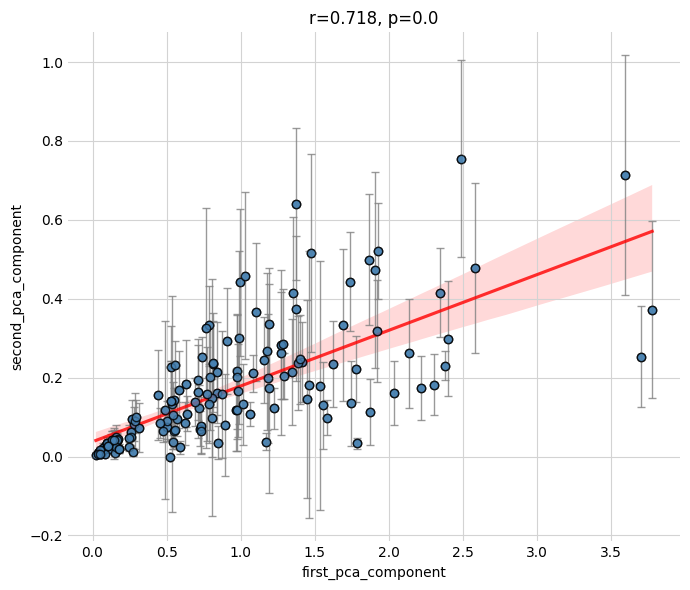

In [38]:
show_correlation(df, 'first_pca_component', 'second_pca_component')

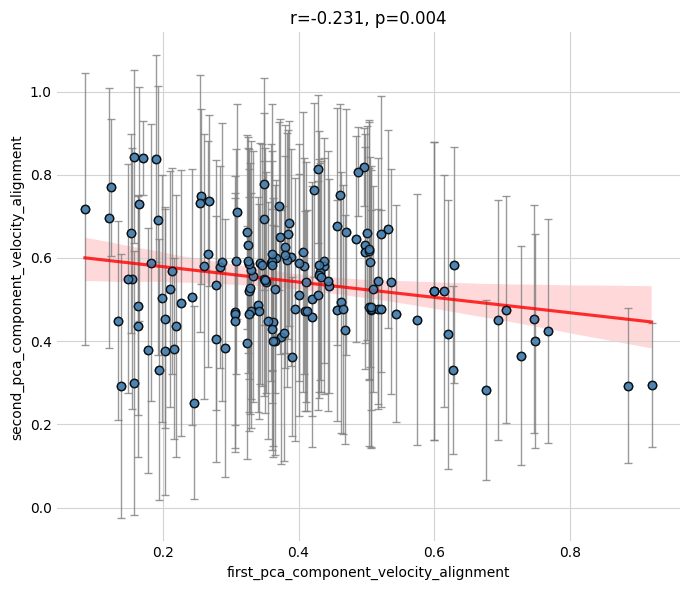

In [39]:
show_correlation(df, 'first_pca_component_velocity_alignment', 'second_pca_component_velocity_alignment')

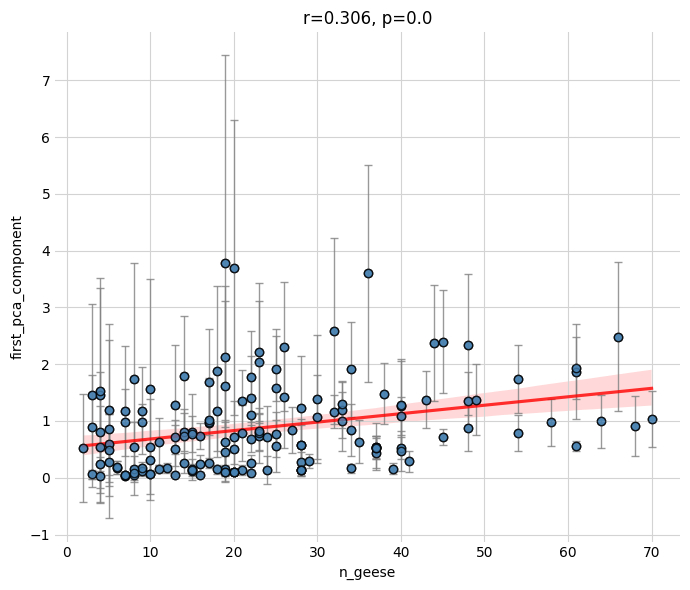

In [40]:
show_correlation(df, 'n_geese', 'first_pca_component')

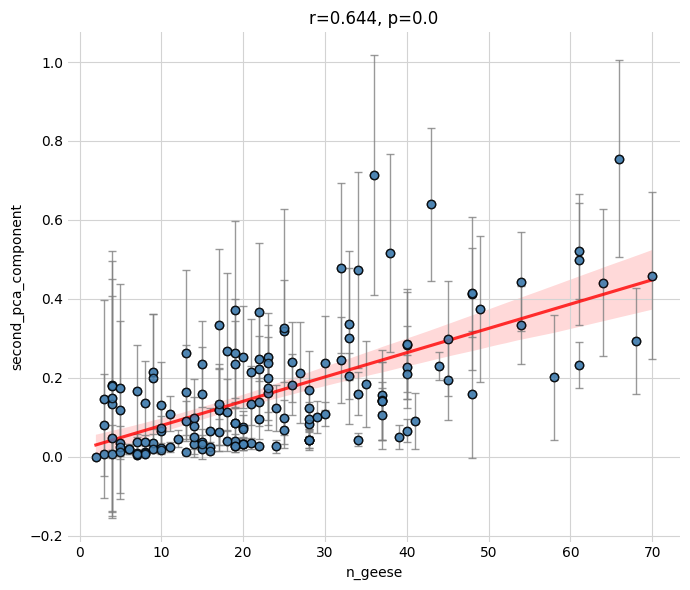

In [41]:
show_correlation(df, 'n_geese', 'second_pca_component')

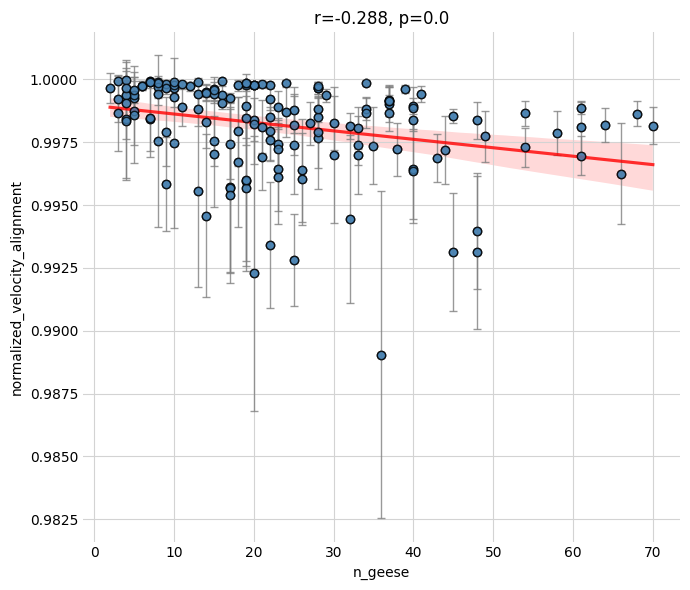

In [42]:
show_correlation(df, 'n_geese', 'normalized_velocity_alignment')

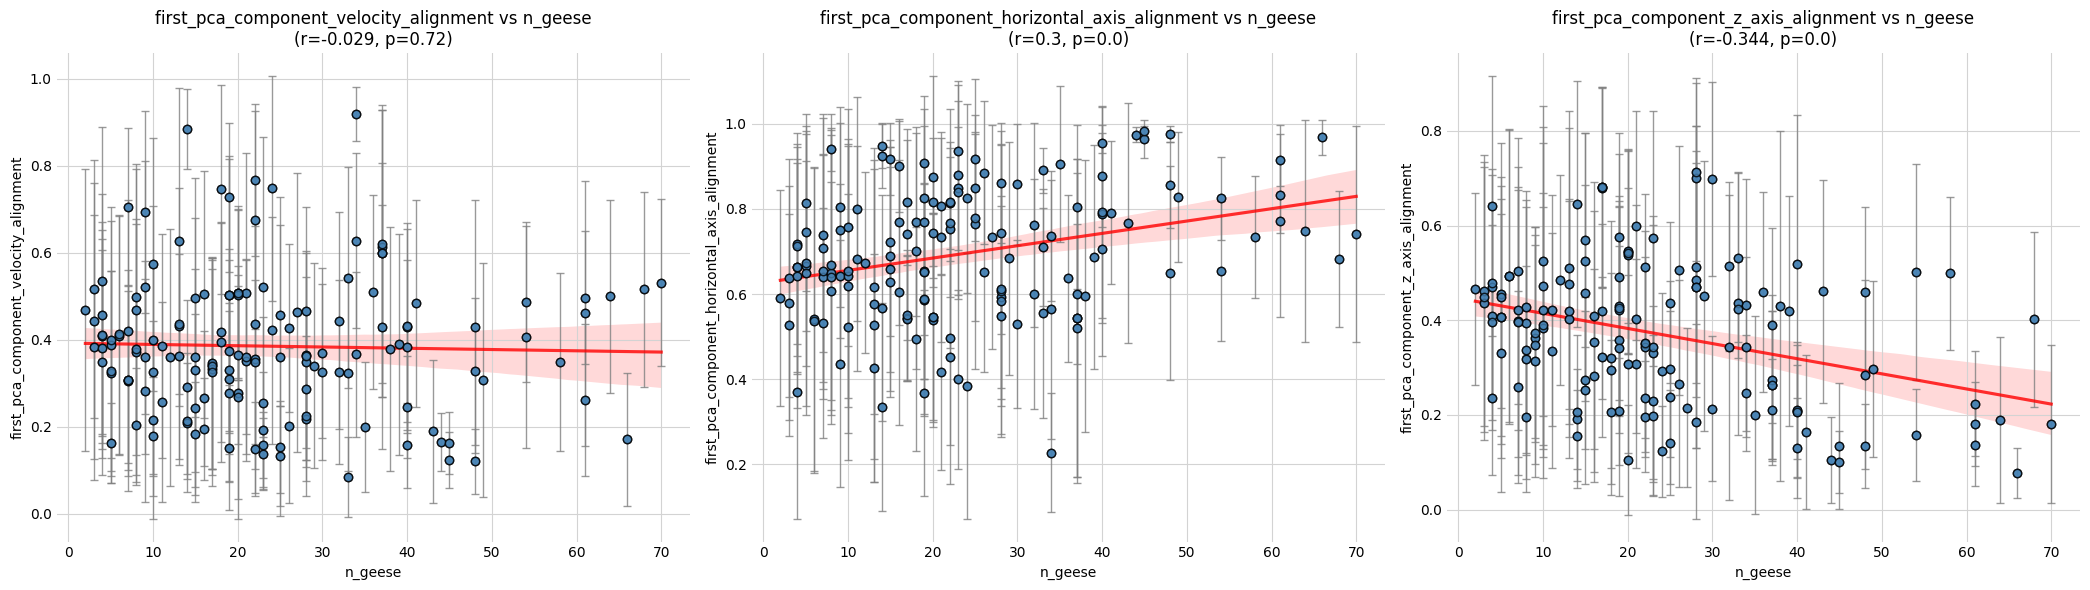

In [43]:
show_correlations(df, 'n_geese', ['first_pca_component_velocity_alignment', 'first_pca_component_horizontal_axis_alignment', 'first_pca_component_z_axis_alignment'])

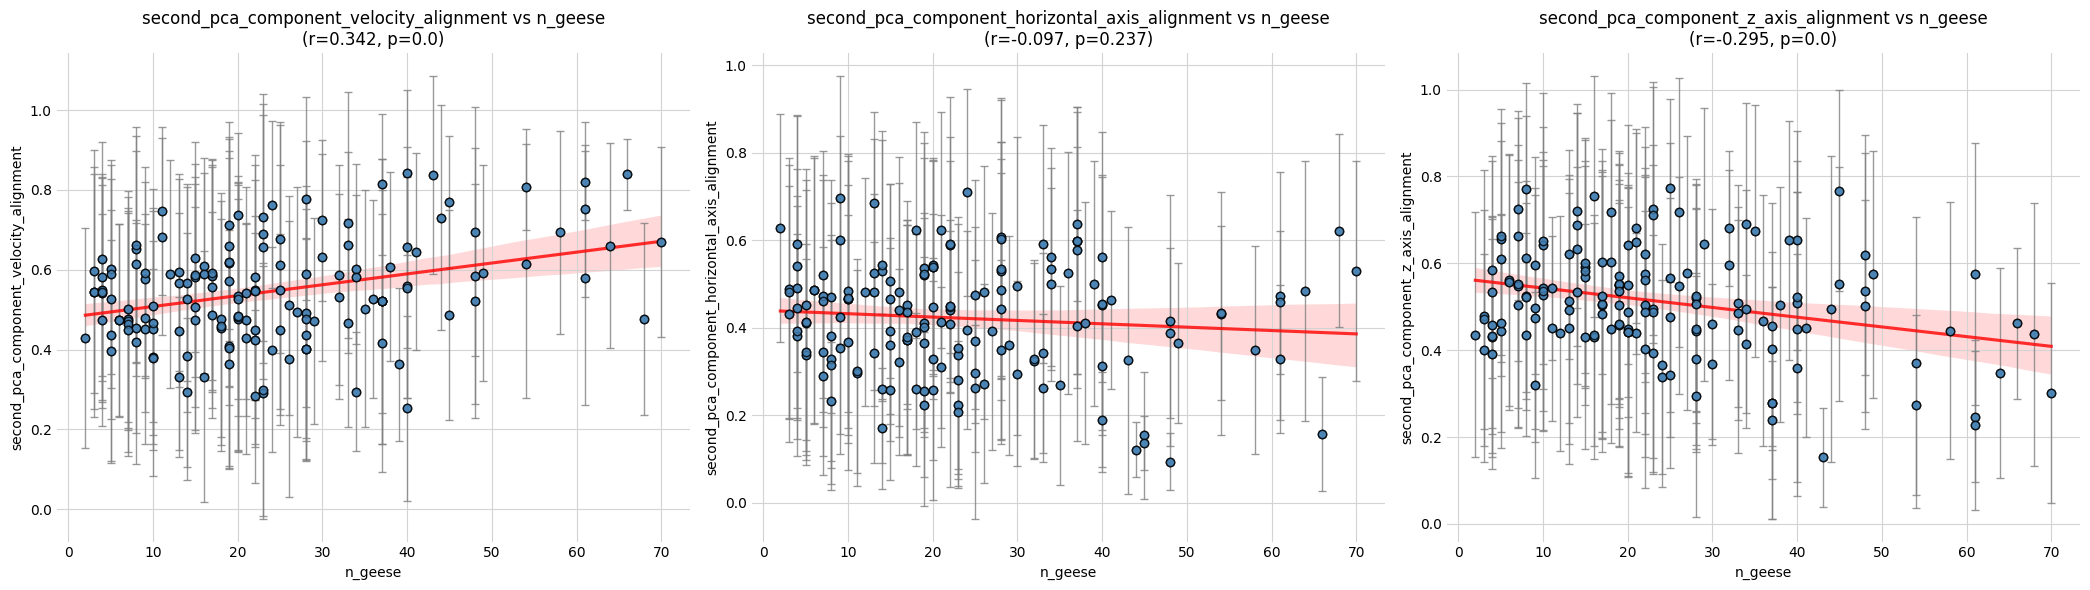

In [44]:

show_correlations(df, 'n_geese', ['second_pca_component_velocity_alignment', 'second_pca_component_horizontal_axis_alignment', 'second_pca_component_z_axis_alignment'])

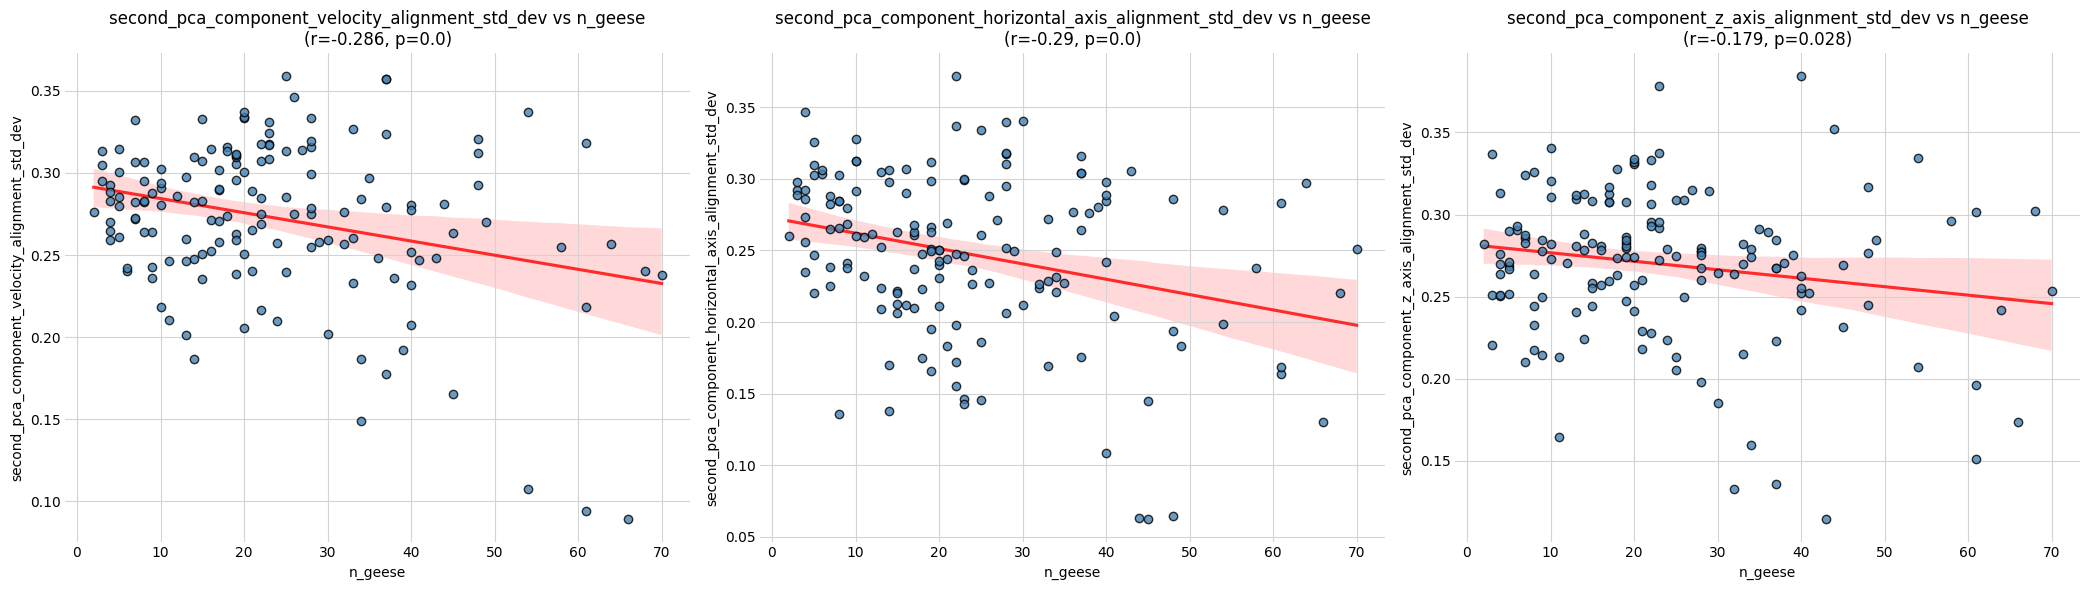

In [45]:
show_correlations(df, 'n_geese', ['second_pca_component_velocity_alignment_std_dev', 'second_pca_component_horizontal_axis_alignment_std_dev', 'second_pca_component_z_axis_alignment_std_dev'])

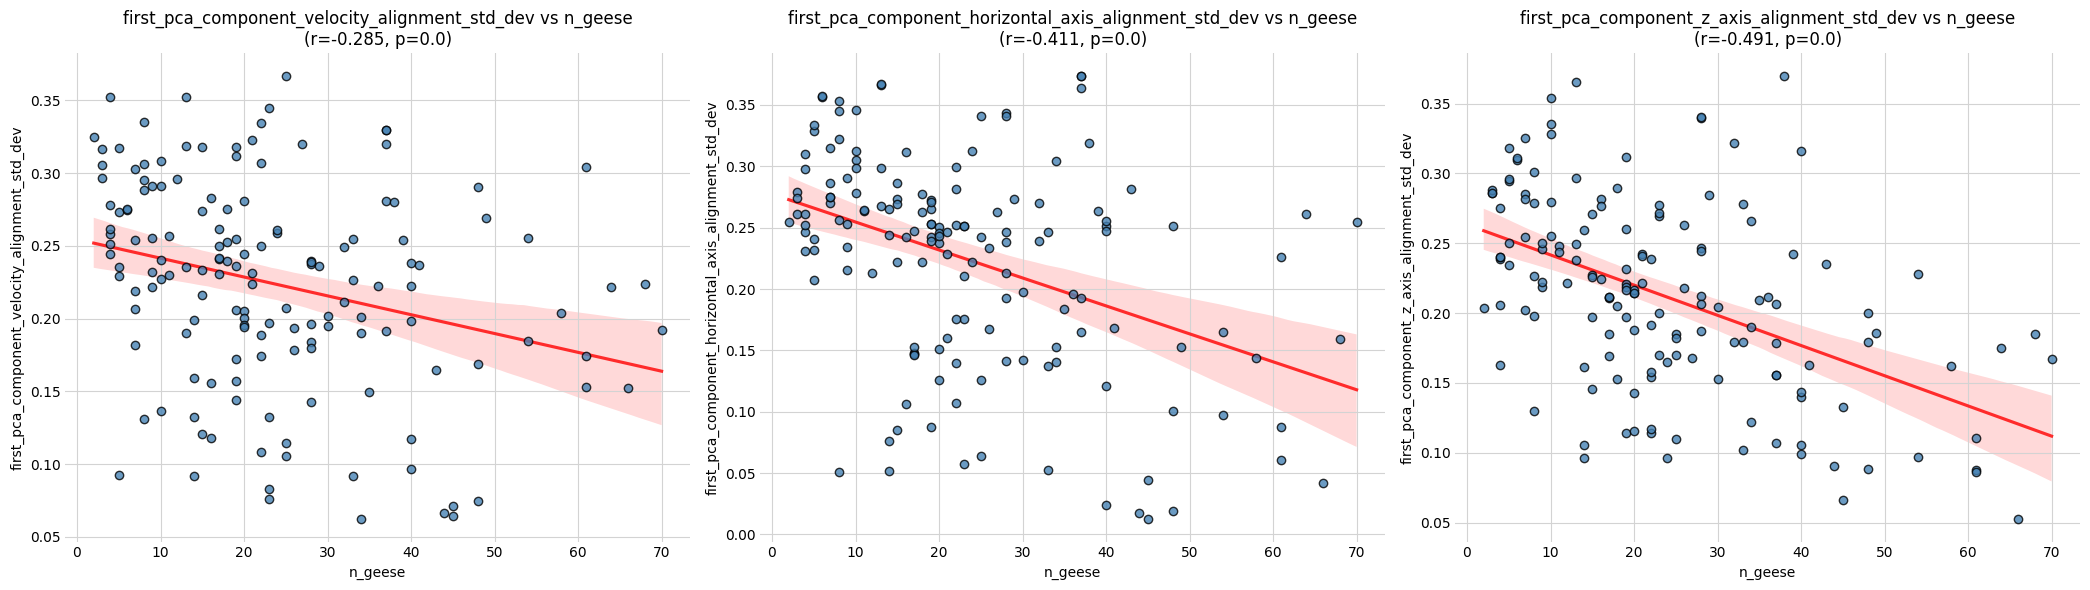

In [61]:
show_correlations(df, 'n_geese', ['first_pca_component_velocity_alignment_std_dev', 'first_pca_component_horizontal_axis_alignment_std_dev', 'first_pca_component_z_axis_alignment_std_dev'])

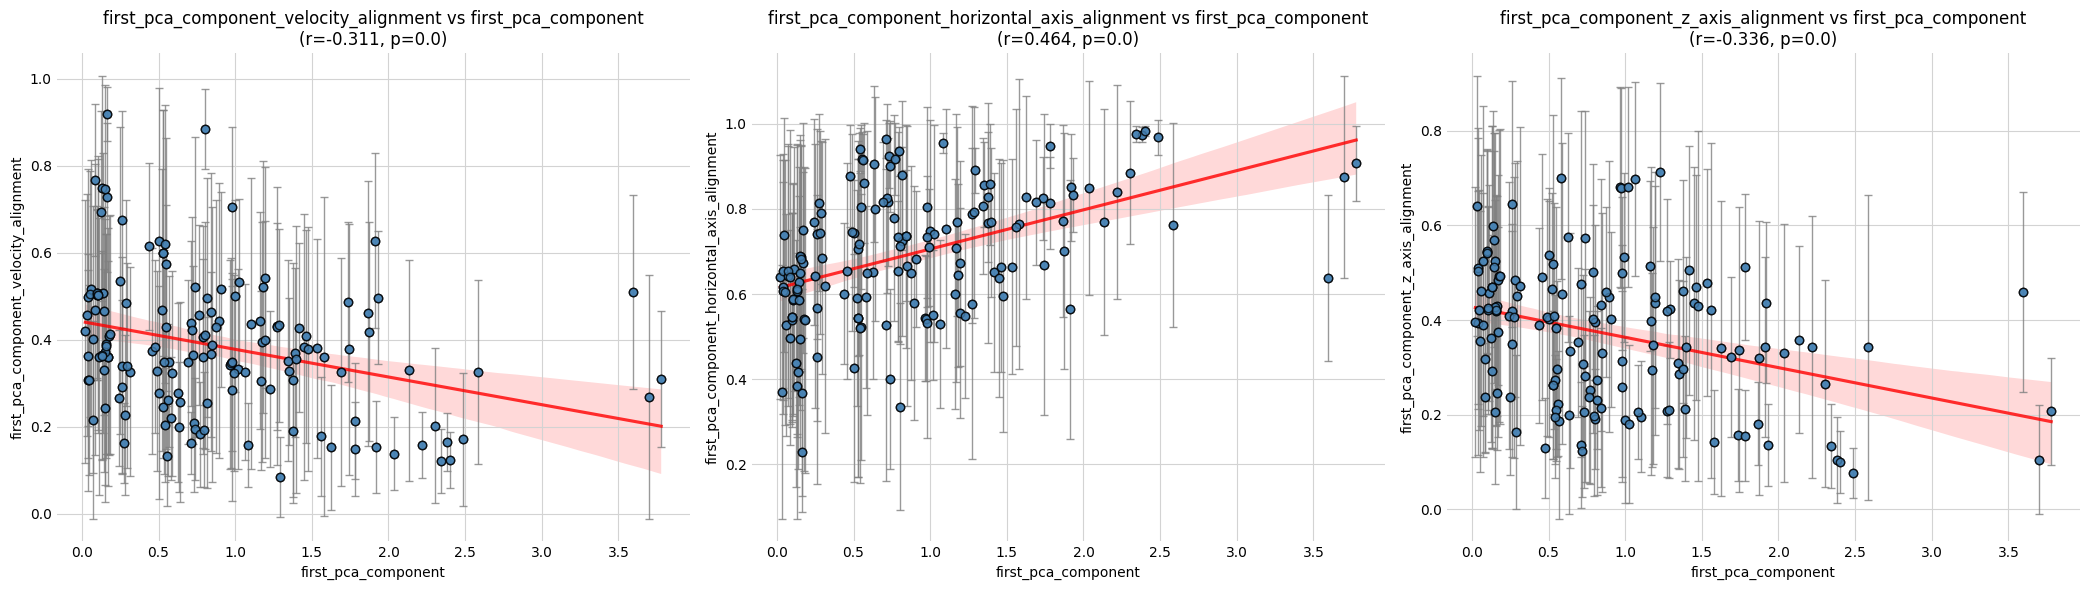

In [46]:
show_correlations(df, 'first_pca_component', ['first_pca_component_velocity_alignment', 'first_pca_component_horizontal_axis_alignment', 'first_pca_component_z_axis_alignment'])

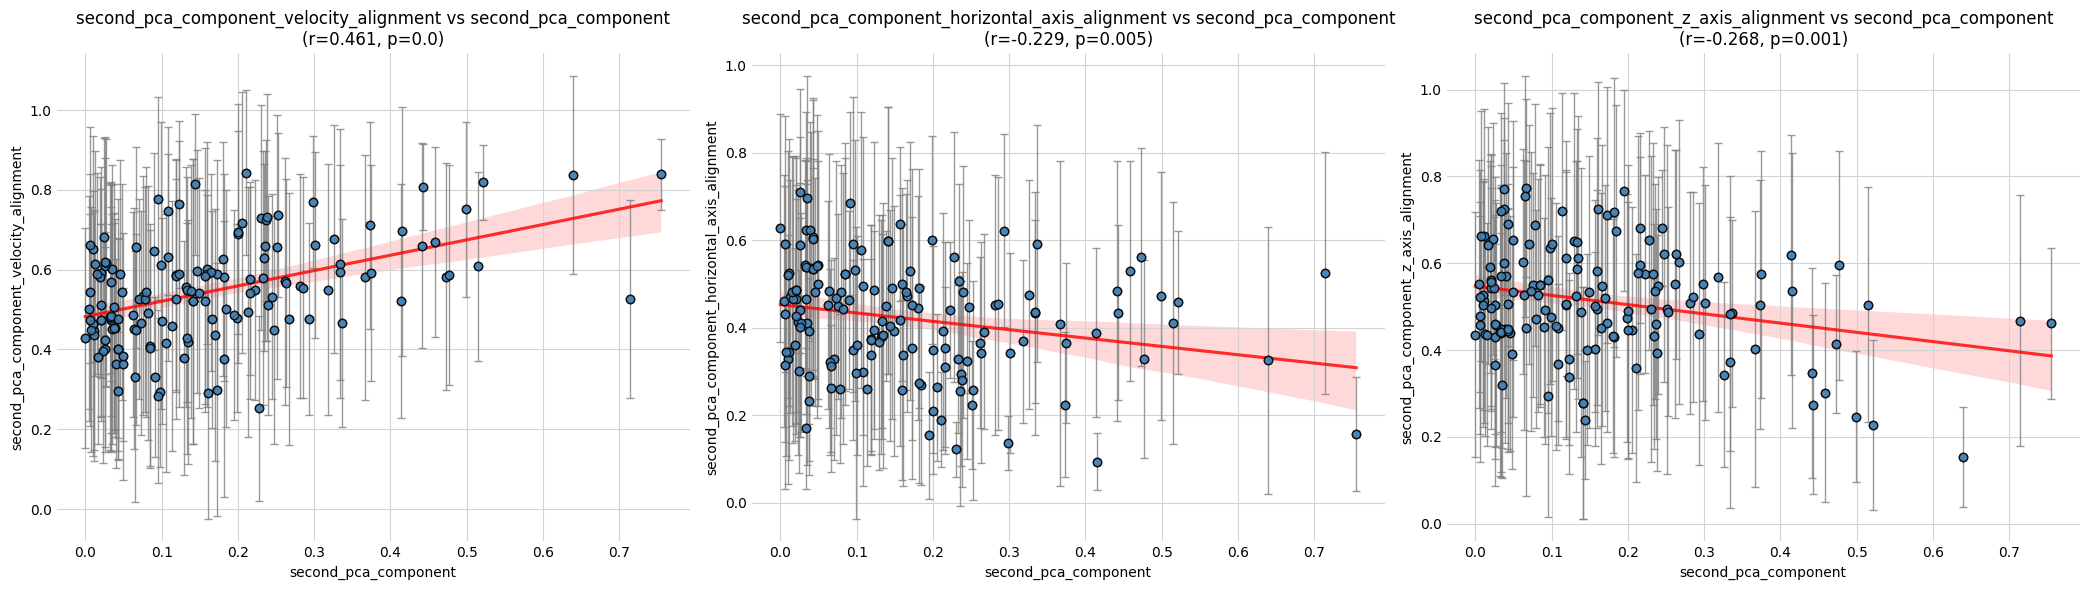

In [47]:
show_correlations(df, 'second_pca_component', ['second_pca_component_velocity_alignment', 'second_pca_component_horizontal_axis_alignment', 'second_pca_component_z_axis_alignment'])

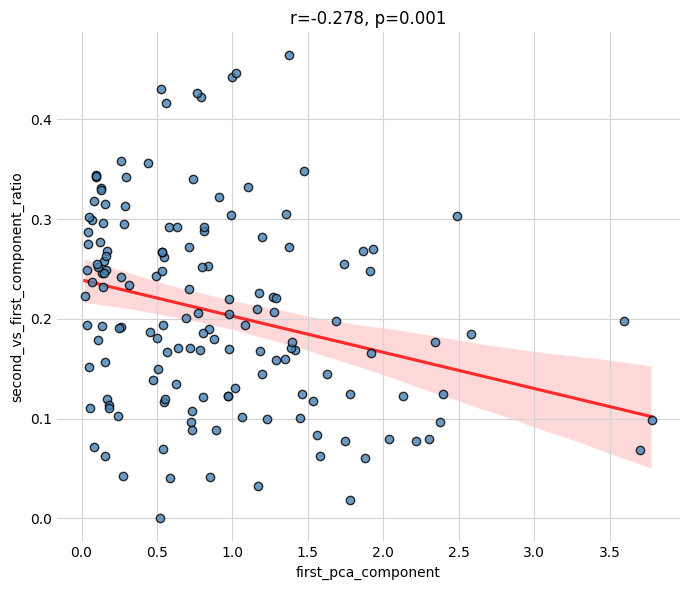

In [48]:
df['second_vs_first_component_ratio'] = df['second_pca_component'] / df['first_pca_component']
show_correlation(df, 'first_pca_component', 'second_vs_first_component_ratio', no_std=True)

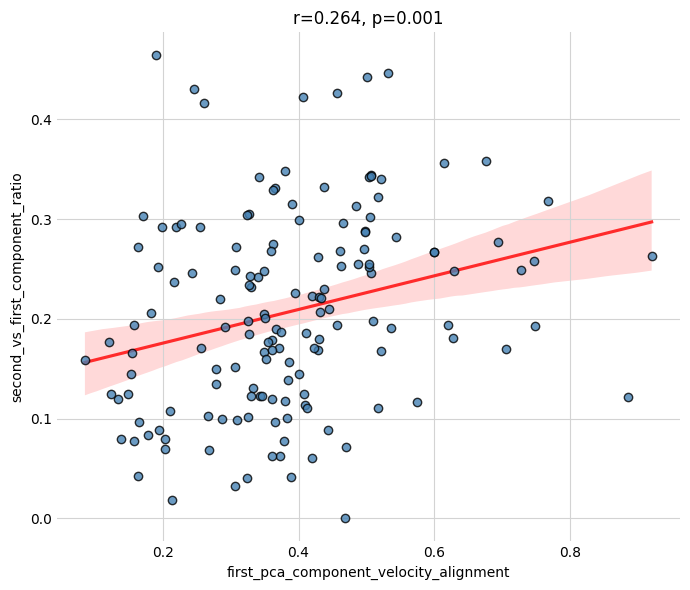

In [49]:
show_correlation(df, 'first_pca_component_velocity_alignment', 'second_vs_first_component_ratio', no_std=True)

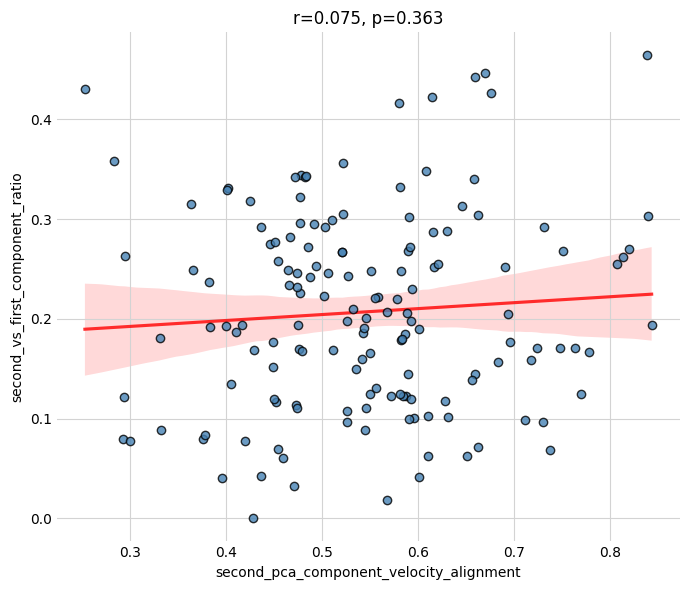

In [50]:
show_correlation(df, 'second_pca_component_velocity_alignment', 'second_vs_first_component_ratio', no_std=True)

In [51]:
wind_df = pd.read_csv('data/metric_means.csv', index_col=0)
print(f"{wind_df.isna().sum().sum()} out of {len(wind_df)} data points are nans")
wind_df = wind_df.dropna()
wind_df['crosswind_speed'] = np.abs(wind_df['crosswind_speed'])

17 out of 164 data points are nans


In [52]:
print(f'Dropping {len(wind_df[wind_df['n_frames'] <= 180])} data_points out of {len(wind_df)}')
wind_df = wind_df[wind_df['n_frames'] > 180]

Dropping 2 data_points out of 147


In [53]:
# print(f"Dropping {len(wind_df[wind_df['normalized_velocity_alignment'] <= 0.96])}")
# wind_df = wind_df[wind_df['normalized_velocity_alignment'] > 0.96]

In [54]:
print(f'Dropping {len(wind_df[wind_df['first_pca_component'] >= 4])} data_points out of {len(wind_df)}')
wind_df = wind_df[wind_df['first_pca_component'] < 4]
wind_df.describe()

Dropping 7 data_points out of 145


,n_geese,n_frames,crosswind_speed,normalized_velocity_alignment,normalized_velocity_alignment_std_dev,velocity_deviation,velocity_deviation_std_dev,sidewise_acceleration_deviation,sidewise_acceleration_deviation_std_dev,longitudinal_acceleration_deviation,...,second_pca_component_velocity_alignment,second_pca_component_velocity_alignment_std_dev,first_pca_component_horizontal_axis_alignment,first_pca_component_horizontal_axis_alignment_std_dev,first_pca_component_z_axis_alignment,first_pca_component_z_axis_alignment_std_dev,second_pca_component_horizontal_axis_alignment,second_pca_component_horizontal_axis_alignment_std_dev,second_pca_component_z_axis_alignment,second_pca_component_z_axis_alignment_std_dev
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,...,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,22.978261,518.630435,0.537183,0.998149,0.001133,0.863558,0.252258,1.487741,0.413052,0.318647,...,0.541410,0.276034,0.691034,0.226329,0.371864,0.213873,0.421991,0.248196,0.515158,0.271358
std,15.020408,129.341684,0.626694,0.001859,0.001141,0.420387,0.169958,0.572628,0.362802,0.140681,...,0.119431,0.040083,0.152129,0.085972,0.142197,0.067672,0.126110,0.057328,0.115174,0.043981
min,2.000000,235.000000,0.000000,0.989044,0.000026,0.152738,0.038841,0.259887,0.089202,0.064296,...,0.252590,0.148744,0.227773,0.012275,0.100301,0.066166,0.093773,0.062234,0.153635,0.114335
25%,11.250000,435.500000,0.000000,0.997428,0.000273,0.469524,0.130639,0.996899,0.221252,0.211706,...,0.471993,0.251868,0.589766,0.165538,0.260293,0.167098,0.331220,0.220542,0.445553,0.251179
50%,20.000000,505.500000,0.361158,0.998671,0.000769,0.832770,0.221582,1.528958,0.301767,0.297139,...,0.542790,0.278823,0.678142,0.247029,0.391672,0.214377,0.431758,0.254338,0.505898,0.275122
75%,32.000000,613.750000,0.857283,0.999487,0.001535,1.194951,0.321023,1.862614,0.446393,0.415727,...,0.606353,0.306880,0.803166,0.275034,0.469327,0.262499,0.517461,0.289992,0.580302,0.295444
max,70.000000,962.000000,2.822452,0.999961,0.006510,2.069859,0.916545,2.850660,2.112263,0.818323,...,0.843432,0.359328,0.982953,0.373913,0.712930,0.370002,0.709074,0.372022,0.773046,0.384658


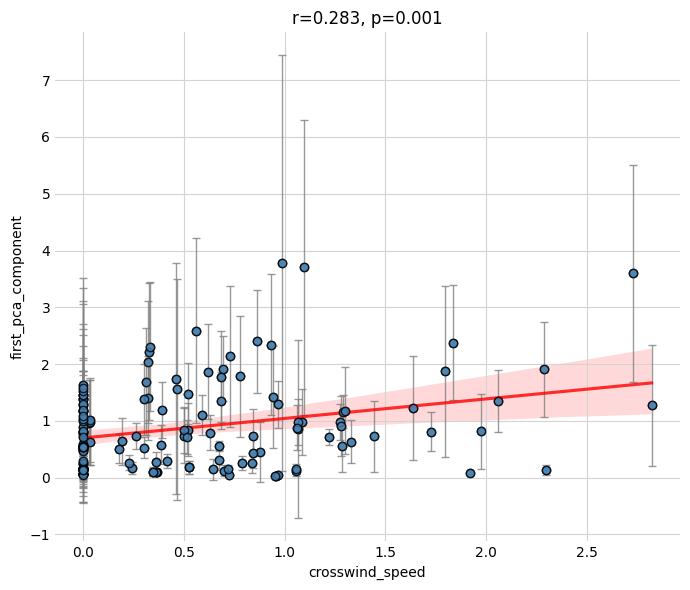

In [55]:
show_correlation(wind_df, 'crosswind_speed', 'first_pca_component')

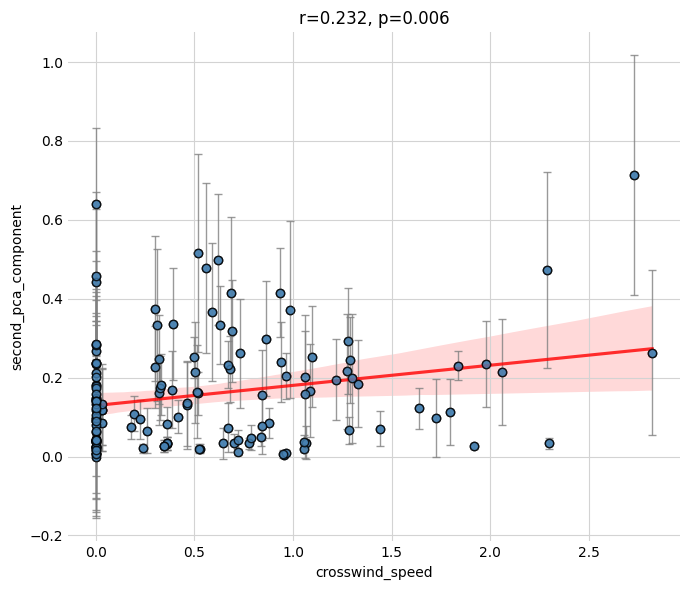

In [56]:
show_correlation(wind_df, 'crosswind_speed', 'second_pca_component')

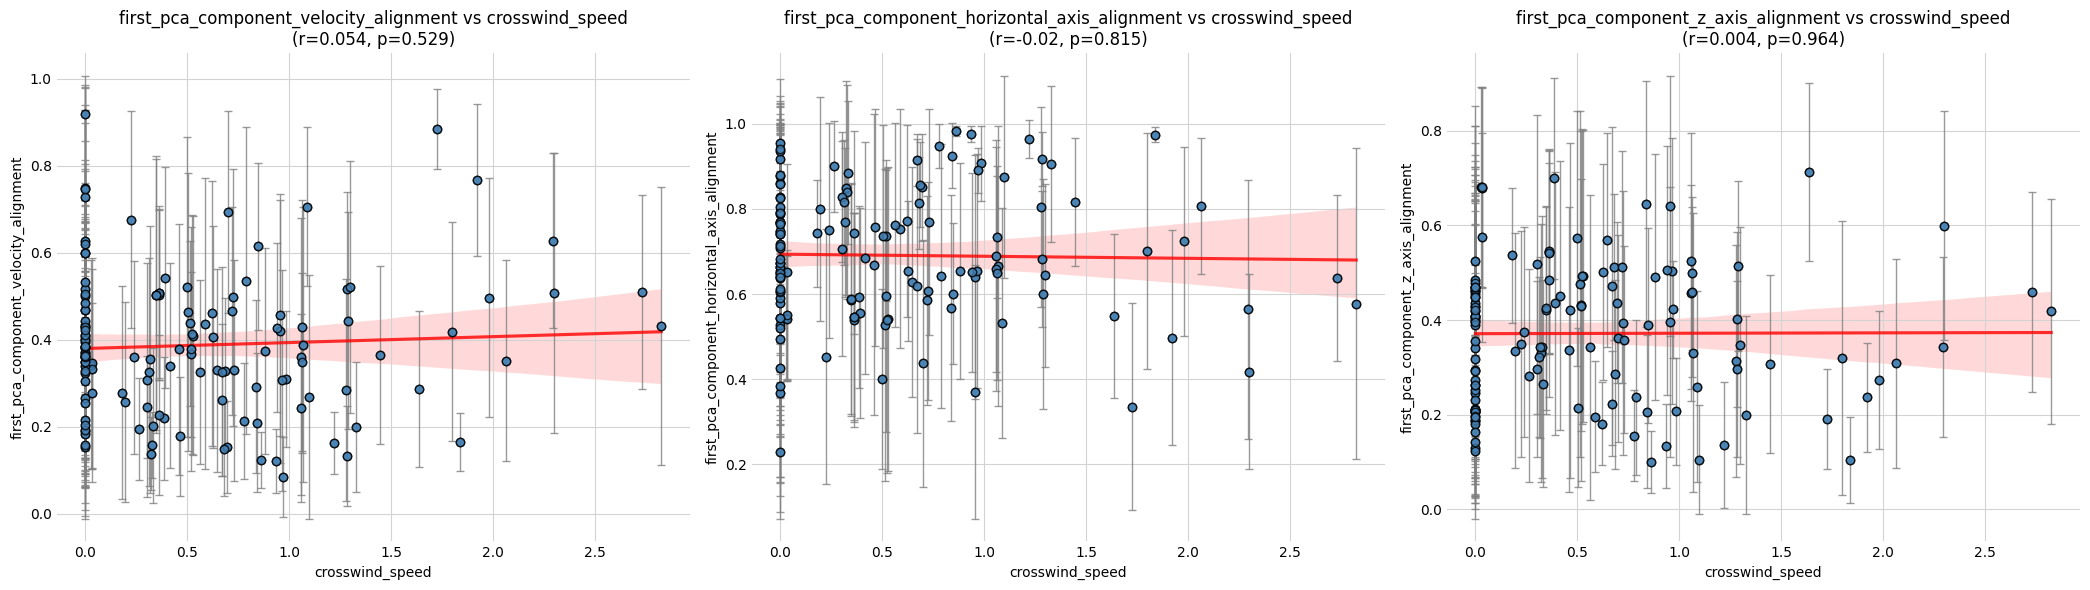

In [57]:
show_correlations(wind_df, 'crosswind_speed', ['first_pca_component_velocity_alignment', 'first_pca_component_horizontal_axis_alignment', 'first_pca_component_z_axis_alignment'])

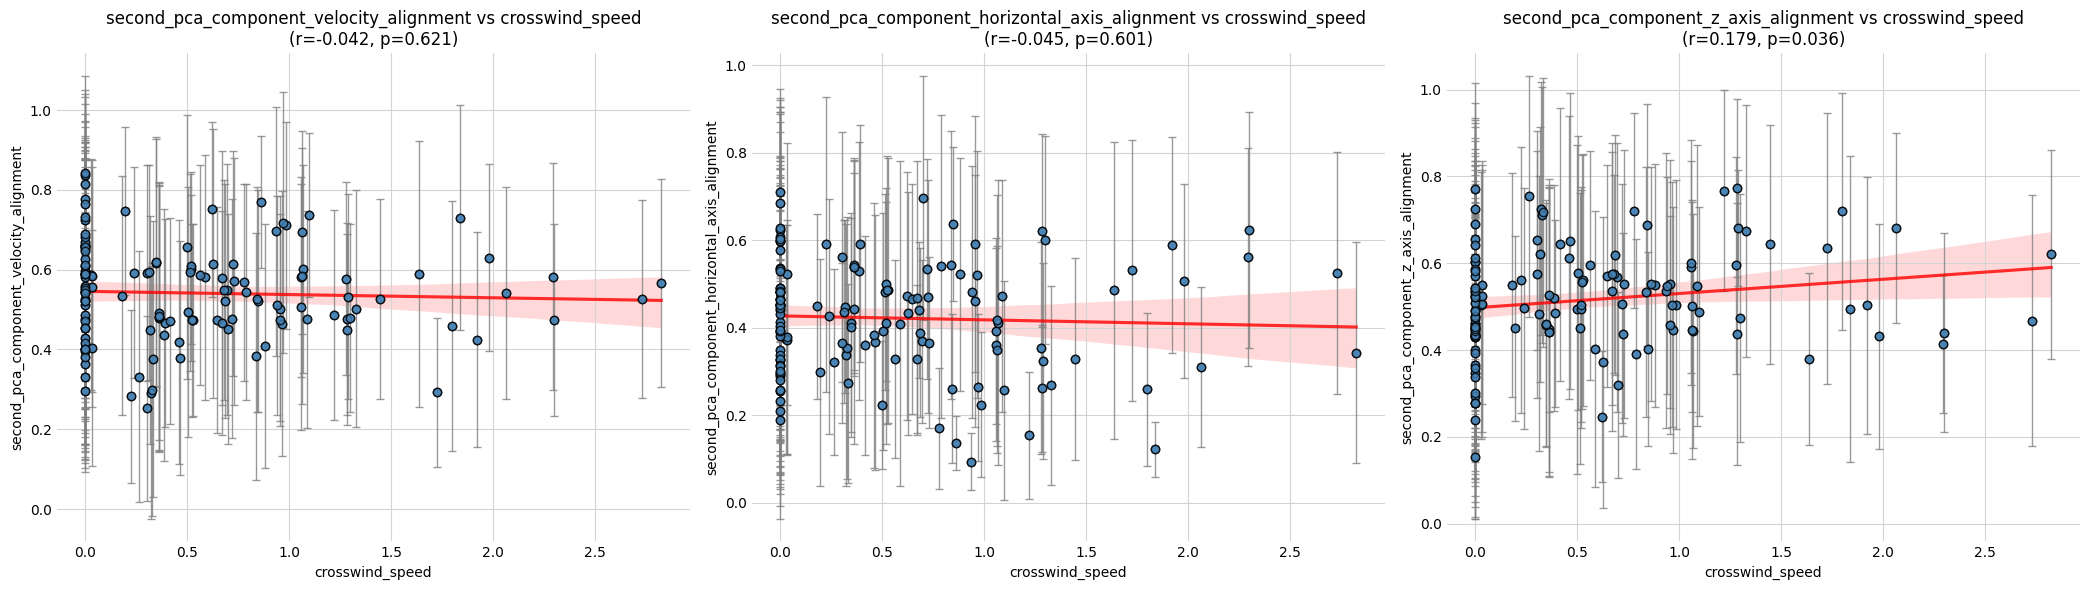

In [58]:
show_correlations(wind_df, 'crosswind_speed', ['second_pca_component_velocity_alignment', 'second_pca_component_horizontal_axis_alignment', 'second_pca_component_z_axis_alignment'])

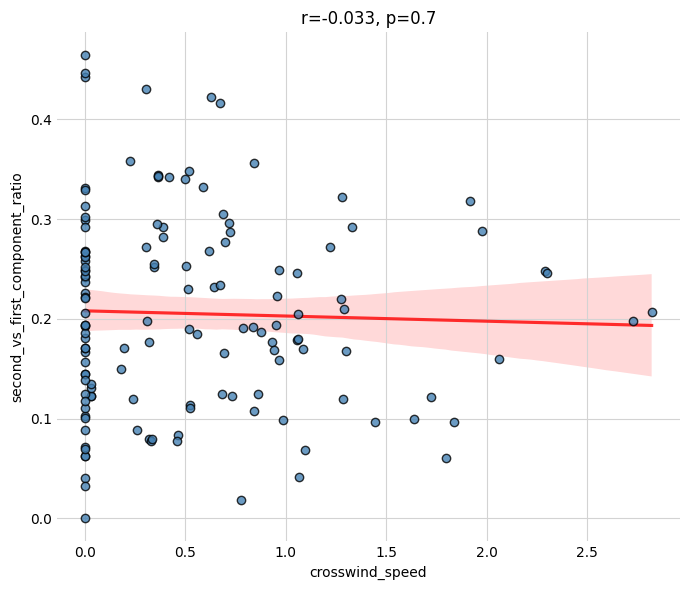

In [59]:
wind_df['second_vs_first_component_ratio'] = wind_df['second_pca_component'] / wind_df['first_pca_component']
show_correlation(wind_df, 'crosswind_speed', 'second_vs_first_component_ratio', no_std=True)

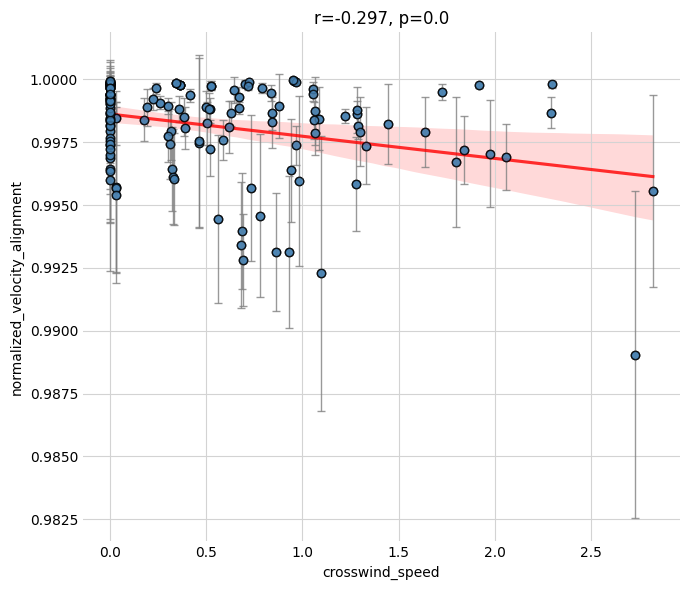

In [60]:
show_correlation(wind_df, 'crosswind_speed', 'normalized_velocity_alignment')